# `gwtf` global-fit mode: per-source PSDs against cold-chain data

This notebook demonstrates the `gf_mode` ("global-fit mode") option of `AnalyticTimeFrequencyWaveform`.

A global fit runs a parallel-tempered sampler: `ntemps` temperature rungs × `nwalkers` walkers, so the
generator is handed `n_sources = nwalkers × ntemps` parameter vectors per call. Two things vary across
those sources, and they vary on *different* axes:

- **PSDs** are sampled alongside the source parameters, so there is one PSD **per source** —
  `psds` has shape `(nwalkers × ntemps, nT, nF, n_channels)`.
- **Data** only exists for the cold chain, so there are only `nwalkers` data realisations —
  `channels` has shape `(nwalkers, nT, nF, n_channels)`.

The `data_indices` argument is the map between them: `data_indices[s]` gives the index into the leading
axis of `channels` that source `s` should be scored against. Source `s` therefore computes

$$\langle d_{\,\mathrm{data\_indices}[s]} \mid h_s \rangle, \qquad
  \langle h_s \mid h_s \rangle$$

with both inner products weighted by **its own** PSD, `psds[s]`.

For contrast, in the default (non-`gf`) mode `channels` and `psds` are single `(nT, nF, n_channels)`
arrays shared by every source in the batch, and `data_indices` must be left as `None`.

> **Note:** `gf_mode` only supports the per-segment statistic kernels. `compute_statistic=True` is
> required, and the semi-coherent search path (`N_seg`) is not supported.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT2Ecc

## The time-frequency grid

Global-fit mode carries one PSD per source, so the PSD array alone costs
`n_sources × nT × nF × n_channels × 8` bytes. We therefore use a coarser frequency grid than the
quickstart (`dt = 20 s`, so `f_max = 25 mHz`) to keep this example to a few hundred MB.

In [2]:
# Define the parameters for the time-frequency grid
dT = 86400 / 4  # 6 hours # SFT time.
nT = 365 * 4  # 1 year # Number of SFT time bins in the total observation
dt = 20  # time step for the *time-domain* data -> used to determine fmax for the SFT
dF = 1 / dT  # Frequency spacing within the SFT.
fmax = 1 / (2 * dt)  # Nyquist frequency for the time-domain data

nF = int((fmax) / dF) + 1  # Number of frequency bins needed to cover the Nyquist frequency.

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,  # Number of frequency bins to use in the fresnel kernel
}

print(f"grid: nT={nT}, nF={nF} -> one (nT, nF, 3) complex array is "
      f"{nT * nF * 3 * 16 / 1e6:.0f} MB")

grid: nT=1460, nF=541 -> one (nT, nF, 3) complex array is 38 MB


## Build the observed data

We build a single time-frequency dataset from two injected sources, using the TDI (AET) channels
(`tdi_type=2`, so `n_channels = 3`). This plays the role of the full data stream; the per-walker
residuals are constructed from it below.

<b>Note: Each walker still dealing with just 1 source at a time, we are emulating RJMCMC here. Just each walker in this context is sampling different sources!</b>

The two injections are deliberately placed close in frequency (4.0 and 4.2 mHz) so that they
**overlap on the time-frequency grid**. That overlap is what makes this example non-trivial: it means
each walker's imperfect subtraction of the second source leaves a residual *underneath* the templates
being scored, so the `nwalkers` data arrays genuinely differ where it matters. Had the confusion
source sat in a disjoint band, every walker would see identical data under its template and the
source -> data map would be unobservable.

In [13]:
# Generator used to synthesise the injected TDI data (default, non-gf mode).
# We also re-use it later as an independent reference for the verification checks.
data_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
)

# Two injected sources whose superposition forms the data.
injection_pars = {
    "M": np.array([30.0, 42.0]),
    "eta": np.array([0.25, 0.20]),
    "cosi": np.array([0.5, 0.2]),
    "e0": np.array([1e-3, 2e-3]),
    "D": np.array([1e3, 1e3]),
    "f0": np.array([4e-3, 4.2e-3]),
    "phi_coal": np.array([0.1, 0.7]),
}

# Response/extrinsic parameters [cosi, pol, ecliptic_long, ecliptic_lat], one row per source.
injection_response = np.array(
    [
        [injection_pars["cosi"][0], np.pi / 6, 5 * np.pi / 4, np.pi / 3],
        [injection_pars["cosi"][1], np.pi / 5, np.pi, np.pi / 4],
    ]
)

# Per-source waveforms, and their sum -> the (nT, nF, 3) AET data array.
injection_waveforms = data_generator(
    injection_pars, parameters_response=injection_response
)
signal = injection_waveforms.sum(0)

PSD_LEVEL = 1e-35  # flat reference PSD on the AET channels
psd = np.ones_like(signal.real) * PSD_LEVEL

print("data shape:", signal.shape, "| psd shape:", psd.shape)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation
data shape: (1460, 541, 3) | psd shape: (1460, 541, 3)


## Set up the temperature × walker grid

We fix an ordering convention and stick to it: sources are laid out as a `(ntemps, nwalkers)` grid
flattened in C order, so source `s = t * nwalkers + w`. Everything with a per-source axis — the
parameters, the PSDs, and `data_indices` — is built on that grid and flattened the same way.

**The data.** In a real global fit, walker `w`'s data is the residual left after subtracting its
current estimate of the *other* source types. We mimic that here by subtracting each walker's own
(slightly scattered) estimate of the second injection, which makes the `nwalkers` data arrays
genuinely different from one another.

**The PSDs.** The noise level is being sampled, so every one of the `nwalkers × ntemps` sources
carries its own PSD. We scatter the PSD slightly, making  the PSD vary with
temperature *and* walker.

In [14]:
ntemps = 3
nwalkers = 4
nsources = ntemps * nwalkers
rng = np.random.default_rng(1729)

# Source layout: (ntemps, nwalkers) flattened in C order -> s = t * nwalkers + w.
temp_grid, walker_grid = np.meshgrid(
    np.arange(ntemps), np.arange(nwalkers), indexing="ij"
)
temp_of_source = temp_grid.ravel()
walker_of_source = walker_grid.ravel()

# data_indices: source -> which of the nwalkers data realisations to score against.
# Every temperature rung of walker w sees walker w's data.
data_indices = walker_of_source.astype(np.int32)

# --- the nwalkers cold-chain data realisations -------------------------------
# Walker w's residual: full data minus that walker's current estimate of injection 1.
# Pretend these are the current best estimates of the injection parameters for each walker.
estimate_pars = {
    "M": rng.uniform(41.0, 43.0, nwalkers),
    "eta": rng.uniform(0.19, 0.21, nwalkers),
    "cosi": np.full(nwalkers, 0.2),
    "e0": np.full(nwalkers, 2e-3),
    "D": np.full(nwalkers, 1e3),
    "f0": rng.uniform(4.15e-3, 4.25e-3, nwalkers),
    "phi_coal": rng.uniform(0.6, 0.8, nwalkers),
}
estimate_response = np.column_stack(
    [
        estimate_pars["cosi"],
        np.full(nwalkers, np.pi / 5),
        np.full(nwalkers, np.pi),
        np.full(nwalkers, np.pi / 4),
    ]
)
# estimate of the signals for each walker, shape (nwalkers, nT, nF, 3)
estimates = data_generator(estimate_pars, parameters_response=estimate_response)

# Estimate of the residuals for each walker, shape (nwalkers, nT, nF, 3)
channels_gf = signal[None] - estimates  # (nwalkers, nT, nF, n_channels)

# --- the nwalkers x ntemps PSDs ----------------------------------------------
# One sampled noise level per source, varying across both temperature and walker.
psd_levels = PSD_LEVEL * rng.uniform(0.9, 1.1, nsources)

# Broadcast the per-source PSD levels to the full (n_sources, nT, nF, n_channels) array.
psds_gf = psd_levels[:, None, None, None] * np.ones(
    (nsources, nT, nF, 3)
)  # (nwalkers x ntemps, nT, nF, n_channels)

print(f"ntemps={ntemps}, nwalkers={nwalkers} -> n_sources={nsources}")
print("channels_gf shape:", channels_gf.shape, " (one per cold-chain walker)")
print("psds_gf shape:    ", psds_gf.shape, " (one per source)")
print("data_indices:     ", data_indices)
print("  reshaped to (ntemps, nwalkers):")
print(data_indices.reshape(ntemps, nwalkers))

ntemps=3, nwalkers=4 -> n_sources=12
channels_gf shape: (4, 1460, 541, 3)  (one per cold-chain walker)
psds_gf shape:     (12, 1460, 541, 3)  (one per source)
data_indices:      [0 1 2 3 0 1 2 3 0 1 2 3]
  reshaped to (ntemps, nwalkers):
[[0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]]


## Source parameters

One parameter vector per source, scattered around the first injection — again laid out on the
`(ntemps, nwalkers)` grid and flattened in C order, so row `s` of the parameter arrays corresponds to
`data_indices[s]` and `psds_gf[s]`.

In [15]:
# Relative width of the intrinsic walker cloud
jitter = 1e-10
scatter = lambda x0: x0 * (1 + rng.uniform(-jitter, jitter, nsources))

walker_pars = {
    "M": scatter(injection_pars["M"][0]),
    "eta": scatter(injection_pars["eta"][0]),
    "cosi": np.full(nsources, injection_pars["cosi"][0]),
    "e0": np.full(nsources, injection_pars["e0"][0]),
    "D": injection_pars["D"][0] * rng.uniform(0.97, 1.03, nsources),
    "f0": scatter(injection_pars["f0"][0]),
    "phi_coal": injection_pars["phi_coal"][0] + rng.uniform(-0.05, 0.05, nsources),
}

# Response parameters, one row per source.
walker_response = np.column_stack(
    [
        walker_pars["cosi"],
        np.full(nsources, np.pi / 6),
        np.full(nsources, 5 * np.pi / 4),
        np.full(nsources, np.pi / 3),
    ]
)

print("parameter rows:", walker_pars["M"].shape[0], "| response:", walker_response.shape)

parameter rows: 12 | response: (12, 4)


## Construct the global-fit generator and evaluate the statistic

`gf_mode=True` is set at construction, and the per-walker `channels` / per-source `psds` may be
supplied either there or at call time. `data_indices` is always a call-time argument, since the
source → data map changes as the sampler swaps temperatures.

The returned array has shape `(n_sources, nT, 2)`, with the last axis holding
$\langle d \mid h \rangle$ and $\langle h \mid h \rangle$ for each time segment.

In [16]:
gf_generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT2Ecc,
    config=config,
    tdi_type=2,
    channels=channels_gf,  # (nwalkers, nT, nF, n_channels)
    psds=psds_gf,  # (nwalkers x ntemps, nT, nF, n_channels)
    gf_mode=True,
)

stat_gf = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    compute_statistic=True,  # required in gf_mode
    data_indices=data_indices,
)

print("per-source statistic shape:", stat_gf.shape)  # (n_sources, nT, 2)

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation
per-source statistic shape: (12, 1460, 2)


Below we plot the cold-chain walkers (`t = 0`), against its own residual data and its own
PSD. The kernel returns *per-segment* inner products, but we plot their running sums here.

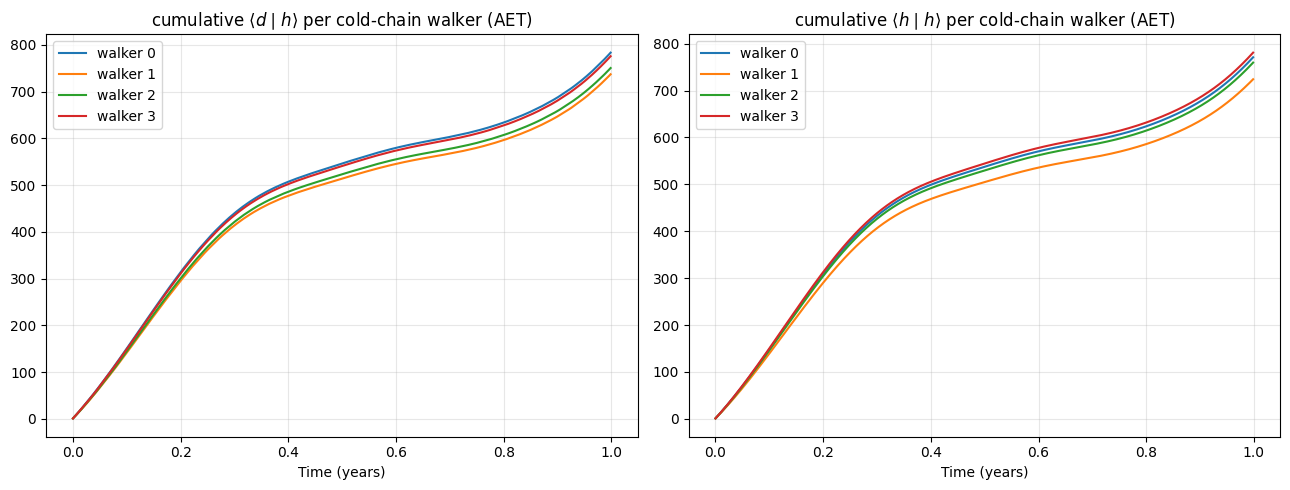

In [17]:
years = gf_generator.t_tranche / (365.25 * 24 * 3600)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for w in range(nwalkers):
    src = 0 * nwalkers + w  # cold chain, temperature index 0
    axes[0].plot(years, np.cumsum(np.real(stat_gf[src, :, 0])), label=f"walker {w}")
    axes[1].plot(years, np.cumsum(np.real(stat_gf[src, :, 1])), label=f"walker {w}")
axes[0].set_title(r"cumulative $\langle d \mid h \rangle$ per cold-chain walker (AET)")
axes[1].set_title(r"cumulative $\langle h \mid h \rangle$ per cold-chain walker (AET)")
for ax in axes:
    ax.set_xlabel("Time (years)")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

A single scalar summary per source is obtained by summing the per-segment inner products over time.
The coherent matched-filter SNR of source `s` is $\langle d\mid h\rangle / \sqrt{\langle h\mid h\rangle}$.

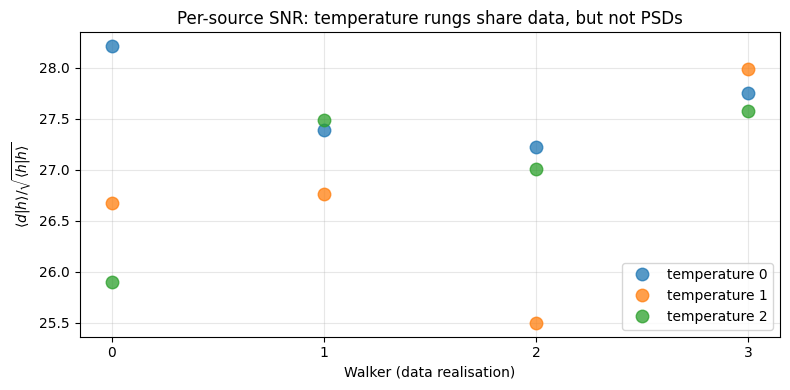

In [18]:
d_h = stat_gf[:, :, 0].sum(axis=1)  # sum over time segments -> (n_sources,)
h_h = stat_gf[:, :, 1].sum(axis=1)
snr = np.real(d_h) / np.sqrt(np.real(h_h))

# Plotted as markers rather than bars: the spread between sources is a few percent,
# which a bar chart would either hide or exaggerate with a non-zero baseline.
fig, ax = plt.subplots(figsize=(8, 4))
for t in range(ntemps):
    sel = temp_of_source == t
    ax.plot(walker_of_source[sel], snr[sel], "o", ms=9, alpha=0.75,
            label=f"temperature {t}")
ax.grid(alpha=0.3)
ax.set_xticks(np.arange(nwalkers))
ax.set_xlabel("Walker (data realisation)")
ax.set_ylabel(r"$\langle d|h\rangle/\sqrt{\langle h|h\rangle}$")
ax.set_title("Per-source SNR: temperature rungs share data, but not PSDs")
ax.legend()
plt.tight_layout()
plt.show()

## Verification 1: exhaustive per-source reference

The strongest check available: for every source `s`, re-evaluate it on its own using the ordinary
shared-data path, handing that generator exactly the data slice `channels_gf[data_indices[s]]` and
the single PSD `psds_gf[s]`. If `gf_mode` is wiring both maps correctly, the two must agree to
floating-point precision for every source.

This also pins down *which* array is indexed by *which* axis: a bug that used `s` where
`data_indices[s]` belongs (or vice versa) would show up here as soon as the data realisations or the
PSDs differ between sources — which, by construction above, they do.

In [19]:
reference = np.empty_like(stat_gf)

for s in range(nsources):
    single_source_pars = {k: v[s : s + 1] for k, v in walker_pars.items()}
    reference[s] = data_generator(
        single_source_pars,
        parameters_response=walker_response[s : s + 1],
        channels=channels_gf[data_indices[s]],  # this source's data realisation
        psds=psds_gf[s],  # this source's own PSD
        compute_statistic=True,
    )[0]

abs_err = np.max(np.abs(stat_gf - reference))
rel_err = np.max(np.abs(stat_gf - reference) / np.abs(reference))
print(f"max absolute difference: {abs_err:.3e}")
print(f"max relative difference: {rel_err:.3e}")
assert np.allclose(stat_gf, reference), "gf_mode disagrees with the per-source reference!"
print("gf_mode matches the per-source reference for all", nsources, "sources.")

max absolute difference: 0.000e+00
max relative difference: 0.000e+00
gf_mode matches the per-source reference for all 12 sources.


## Verification 2: the degenerate case reproduces the shared-data path

If every walker is given the *same* data and every source the *same* PSD, global-fit mode must
reproduce exactly what the ordinary shared-data path computes for the same batch of parameters. This
guards the `gf_mode` branch against drifting away from the default one.

In [21]:
channels_same = np.repeat(signal[None], nwalkers, axis=0)
psds_same = np.repeat(psd[None], nsources, axis=0)

stat_degenerate = gf_generator(
    walker_pars,
    parameters_response=walker_response,
    channels=channels_same,  # call-time arrays override the stored ones
    psds=psds_same,
    compute_statistic=True,
    data_indices=data_indices,
)

# Ordinary shared-data path: one (nT, nF, n_channels) data array shared across the batch.
stat_shared = data_generator(
    walker_pars,
    parameters_response=walker_response,
    channels=signal,
    psds=psd,
    compute_statistic=True,
)

print("max abs difference:", np.max(np.abs(stat_degenerate - stat_shared)))
assert np.allclose(stat_degenerate, stat_shared)
print("gf_mode reproduces the shared-data result when data and PSDs are degenerate")

max abs difference: 0.0
gf_mode reproduces the shared-data result when data and PSDs are degenerate
